# 04 - Measuring an encoder: the frozen probe

**What this step does.** Builds the measuring instrument the whole experiment
depends on: a linear probe on a frozen encoder, with early stopping on
validation and a metric chosen per domain. Then runs **arm B** (random-init)
and **arm C** (from-scratch) on one fold, so there is a floor and a ceiling to
read every later result against.

**Why it exists.** Arms A and D are only meaningful relative to something.

- **Arm B, random-init**, is the floor. It answers "how much of the score comes
  from the architecture and the graph alone, before any learning?" On these
  graphs that turns out to be a lot, so it is a demanding floor rather than a
  formality.
- **Arm C, from-scratch**, is the ceiling. It answers "what does this
  architecture achieve if you forget transfer entirely and just train on the
  target labels?" A frozen arm approaching it means the frozen representation
  already carries nearly everything the task needs.

**Why a linear probe, and why frozen.** We want to know what the *encoder*
learned, not what a classifier can extract given enough capacity. A single
linear layer can only read what is already linearly available in the
representation, so its score is a statement about the embedding. A deeper
probe could learn the task largely on its own and would blur the very
difference between arms we are trying to measure.

**What could go wrong.**
- **An under-trained probe.** This nearly happened, and it is the main story
  of section 3. A probe stopped before it converges understates every arm -
  and not necessarily equally.
- **Early stopping that peeks at test.** Validation only, always. Test is read
  exactly once, at the very end.
- **The wrong metric.** Accuracy on Elliptic would make a model that never
  finds a single illicit transaction look 90% correct.
- **A label-fraction sweep that loses a class.** At 1% of Elliptic's training
  nodes, a naive random draw can contain no positives at all.

## Setup

One fold, one seed, all four domains. The full protocol (4 folds x 3 seeds)
comes in notebooks 05 and 06; here we are building and checking the
instrument, not collecting results.

In [1]:
import pathlib
import sys

_here = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [_here, *_here.parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(PROJECT_ROOT)) if str(PROJECT_ROOT) not in sys.path else None

import numpy as np
import pandas as pd
import torch

from src import (batching, config, datasets, features, metrics, models,
                 plotting, pretrain, probe, splits)
from src.seeding import set_seed

SEED = 0
set_seed(SEED)
plotting.use_project_style()
device = config.get_device()
pd.set_option("display.width", 170)

DOMAINS = datasets.DOMAIN_ORDER

prepared = {}
for name in DOMAINS:
    d = features.symmetrize_domain(datasets.load_domain(name, verbose=False), verbose=False)
    sp = splits.make_node_split(d, seed=SEED)
    st = features.structural_features_for_domain(d, verbose=False)
    X, _, _ = features.build_unified_features(
        d, sp, seed=SEED, svd_scaling="block", structural=st, verbose=False
    )
    prepared[name] = {"domain": d, "split": sp, "X": X, "y": splits.pooled_labels(d)}
    print(f"  {name:<9} X{X.shape}  train {len(sp.train_idx):>6,}  "
          f"val {len(sp.val_idx):>6,}  test {len(sp.test_idx):>6,}  task={d.task}")

print(f"\ndevice: {device}")

  cora      X(2708, 133)  train  1,624  val    542  test    542  task=multiclass


  photo     X(7650, 133)  train  4,590  val  1,530  test  1,530  task=multiclass


  ppi       X(56944, 133)  train 34,166  val 11,389  test 11,389  task=multilabel


  elliptic  X(203769, 133)  train 27,938  val  9,313  test  9,313  task=binary

device: cuda


## 1. One metric per domain, chosen from the data

Notebook 01 measured the label structure; this is where those measurements
turn into a decision. Using one metric for all four would be actively
misleading.

| domain | headline metric | why |
|---|---|---|
| Cora, Photo | **accuracy** | ordinary multi-class, worst imbalance 5.9x |
| PPI | **micro-F1** | multi-label - a node holds ~37 of 121 labels, so "accuracy" is undefined |
| Elliptic | **AUC-PR** | 9.2x imbalanced; accuracy rewards never finding a fraud |

The baselines below are what you score with **no model at all**. Every number
in this project should be read against its own row here - especially
Elliptic's, where predicting "licit" for everything scores 90%.

In [2]:
rows = []
for name, p in prepared.items():
    d, sp, y = p["domain"], p["split"], p["y"]
    pm = metrics.primary_metric_for(name, d.task)
    base = metrics.majority_baseline(d.task, y[sp.test_idx])
    rows.append({
        "domain": name,
        "task": d.task,
        "headline_metric": pm,
        "baseline_value": base.get(pm, float("nan")),
        "baseline_accuracy": base.get("accuracy", float("nan")),
        "test_nodes": len(sp.test_idx),
    })

display(pd.DataFrame(rows).set_index("domain"))
print("\nNote Elliptic: a no-model baseline scores 0.90 ACCURACY but only 0.098 AUC-PR.")
print("That gap is exactly why the headline metric there is AUC-PR.")

,task,headline_metric,baseline_value,baseline_accuracy,test_nodes
domain,,,,,
cora,multiclass,accuracy,0.300738,0.300738,542
photo,multiclass,accuracy,0.253595,0.253595,1530
ppi,multilabel,micro_f1,0.392105,NaN,11389
elliptic,binary,auc_pr,0.097605,0.902395,9313



Note Elliptic: a no-model baseline scores 0.90 ACCURACY but only 0.098 AUC-PR.
That gap is exactly why the headline metric there is AUC-PR.


## 2. The label-efficiency sweep

Only the **training** set shrinks. Validation and test stay at full size in
every single run, so a 1% point and a 100% point are scored on exactly the
same nodes - the curve then measures label efficiency rather than evaluation
noise.

The subsample is taken **per class** for single-label domains. On Elliptic,
where the illicit class is 9.8% of labelled nodes, a naive 1% random draw
would sometimes contain no positives at all and the probe would have nothing
to learn from. PPI is multi-label, so there is no single class to stratify on
and it gets a uniform draw.

In [3]:
FRACTIONS = [0.01, 0.05, 0.10, 0.50, 1.00]

for name in ["cora", "elliptic", "ppi"]:
    p = prepared[name]
    print(f"\n--- {name} ---")
    display(splits.label_fraction_report(p["split"], p["y"], p["domain"].task,
                                         FRACTIONS, seed=SEED))


--- cora ---


,train_nodes,of_full_train,smallest_class,classes_present
fraction,,,,
0.01,17,0.010468,1,7
0.05,81,0.049877,5,7
0.10,163,0.100369,11,7
0.50,814,0.501232,54,7
1.00,1624,1.000000,108,7



--- elliptic ---


,train_nodes,of_full_train,smallest_class,classes_present
fraction,,,,
0.01,279,0.009986,27,2
0.05,1397,0.050004,136,2
0.10,2794,0.100007,273,2
0.50,13970,0.500036,1364,2
1.00,27938,1.000000,2727,2



--- ppi ---


,train_nodes,of_full_train,labels_never_positive
fraction,,,
0.01,342,0.010010,0
0.05,1708,0.049991,0
0.10,3417,0.100012,0
0.50,17083,0.500000,0
1.00,34166,1.000000,0


Note the `smallest_class` column for Elliptic at 1%: the per-class draw keeps
positives in the training set. `classes_present` stays at the full count for
every fraction, which is the property we need.

## 3. The probe had to be fixed before it could measure anything

The first version of this probe used the settings in the original plan - 300
epochs, learning rate 0.01, patience 30. Every domain ran the full 300 epochs
**without early stopping ever triggering**, which is the tell-tale sign that
validation was still improving when the budget ran out. The probe was not
converging; it was being cut off.

That is not a small effect:

| Elliptic AUC-PR | |
|---|---|
| 300 epochs, lr 0.01 | 0.454 |
| converged | **0.663** |

A 46% relative understatement. Worse, different encoders produce differently
*conditioned* embeddings, so an under-trained probe does not understate every
arm equally - it quietly favours whichever arm is easier to optimise. That is
the same class of mistake as the uncalibrated BatchNorm in notebook 03.

Two changes fix it, and both are **optimiser** settings shared identically by
every arm, so neither can favour one arm over another:

1. **Standardize the embeddings** (fit on training nodes, no labels involved).
   A linear probe on standardized features spans exactly the same function
   class, so the optimum is unchanged - only the path to it gets shorter. PPI
   went from 1,991 epochs to 79.
2. **A budget large enough to reach a plateau**: lr 0.5, up to 3000 epochs,
   patience 200.

The check that matters is below: `converged` must be True everywhere. If it is
False, the number is a lower bound, not a measurement.

In [4]:
arm_b = {}
rows = []
for name, p in prepared.items():
    d, sp, X, y = p["domain"], p["split"], p["X"], p["y"]

    # Arm B: untrained encoder, BatchNorm calibrated (notebook 03, section 5.1)
    encoder = pretrain.random_init_encoder(d, X, device, seed=SEED)
    emb = batching.full_embeddings(encoder, d, X, device)
    arm_b[name] = emb

    res = probe.train_linear_probe(
        emb, y, sp.train_idx, sp.val_idx, sp.test_idx,
        d.task, d.num_classes, name, device, seed=SEED,
    )
    pm = metrics.primary_metric_for(name, d.task)
    rows.append({
        "domain": name,
        "metric": pm,
        "test_score": res.test_metrics[pm],
        "val_score": res.val_metrics[pm],
        "baseline": metrics.majority_baseline(d.task, y[sp.test_idx]).get(pm, np.nan),
        "best_epoch": res.best_epoch,
        "converged": res.stopped_early,
        "seconds": res.seconds,
    })

probe_check = pd.DataFrame(rows).set_index("domain")
display(probe_check)

assert probe_check["converged"].all(), (
    "a probe hit the epoch cap without plateauing -- its score is a lower "
    "bound, not a measurement"
)
print("\nEvery probe reached a validation plateau. The instrument is trustworthy.")

,metric,test_score,val_score,baseline,best_epoch,converged,seconds
domain,,,,,,,
cora,accuracy,0.765683,0.795203,0.300738,354,True,1.284789
photo,accuracy,0.871895,0.890850,0.253595,542,True,1.683981
ppi,micro_f1,0.532713,0.533187,0.392105,226,True,6.801726
elliptic,auc_pr,0.660593,0.660274,0.097605,1752,True,16.158156



Every probe reached a validation plateau. The instrument is trustworthy.


## 4. Arm B and arm C on one fold

Arm B is the floor, arm C the ceiling. Both use identical splits, identical
seeds and identical scoring code - the only thing that differs is whether the
encoder is trained on the target's labels.

Arm C trains the encoder and head together, end to end, which is slower.
Elliptic uses the same 2-hop subgraph batching as pretraining.

One subtlety had to be fixed here too. An **epoch** must mean one pass over
the data, not one batch. Cora is a single batch, but PPI is 24 graphs and
Elliptic is 5 sampled subgraphs, so "200 epochs" meant 200 passes for Cora and
8 for PPI -- and the two arms were not comparably trained. PPI's arm C scored
0.497 micro-F1 that way, *below* its own arm B floor, which is impossible for
a genuine upper bound and was the clue. Trained per-pass it reaches 0.885.

Related: the number of batches in a pass is now measured rather than assumed.
A 2-hop subgraph grown from 4,096 seeds on Elliptic contains ~50,000 nodes, so
covering its 203,769 takes about 5 batches -- not the 49 that counting seeds
alone suggests.

In [5]:
results = []
for name, p in prepared.items():
    d, sp, X, y = p["domain"], p["split"], p["X"], p["y"]
    pm = metrics.primary_metric_for(name, d.task)
    base = metrics.majority_baseline(d.task, y[sp.test_idx]).get(pm, np.nan)

    res_b = probe.train_linear_probe(
        arm_b[name], y, sp.train_idx, sp.val_idx, sp.test_idx,
        d.task, d.num_classes, name, device, seed=SEED,
    )
    print(f"  {name:<9} arm B done ({res_b.seconds:.1f}s)", flush=True)

    set_seed(SEED)
    res_c = probe.train_end_to_end(
        models.build_encoder(), d, X, y, sp.train_idx, sp.val_idx, sp.test_idx,
        d.task, d.num_classes, name, device, epochs=300, lr=1e-3,
        patience=50, seed=SEED,
    )
    print(f"  {name:<9} arm C done ({res_c.seconds:.1f}s)", flush=True)

    results.append({
        "domain": name, "metric": pm, "baseline": base,
        "B_random": res_b.test_metrics[pm],
        "C_scratch": res_c.test_metrics[pm],
        "B_epochs": res_b.best_epoch, "C_epochs": res_c.best_epoch,
        "B_converged": res_b.stopped_early, "C_converged": res_c.stopped_early,
    })

arms = pd.DataFrame(results).set_index("domain")
arms["headroom_C_over_B"] = arms["C_scratch"] - arms["B_random"]
display(arms)

  cora      arm B done (1.3s)


  cora      arm C done (1.5s)


  photo     arm B done (1.7s)


  photo     arm C done (12.3s)


  ppi       arm B done (6.8s)


  ppi       arm C done (150.1s)


  elliptic  arm B done (15.8s)


  elliptic  arm C done (183.1s)


,metric,baseline,B_random,C_scratch,B_epochs,C_epochs,B_converged,C_converged,headroom_C_over_B
domain,,,,,,,,,
cora,accuracy,0.300738,0.765683,0.832103,354,27,True,True,0.066421
photo,accuracy,0.253595,0.871895,0.932026,542,142,True,True,0.060131
ppi,micro_f1,0.392105,0.532713,0.891346,226,281,True,False,0.358634
elliptic,auc_pr,0.097605,0.660593,0.950328,1752,281,True,False,0.289735


### What the floor and ceiling say

The gap between arm B and arm C is the space any transfer result has to live
in. If it is narrow, a random encoder already captures nearly everything the
architecture can extract, and there is very little room for pretraining to
demonstrate anything - a fact worth knowing *before* reading arm A, not after.

In [6]:
print("Room available for pretraining to prove itself:\n")
for name, row in arms.iterrows():
    span = row["headroom_C_over_B"]
    floor_gain = row["B_random"] - row["baseline"]
    print(f"  {name:<9} ({row['metric']})")
    print(f"     no-model baseline  {row['baseline']:.4f}")
    print(f"     B random-init      {row['B_random']:.4f}   (+{floor_gain:.4f} over baseline)")
    print(f"     C from-scratch     {row['C_scratch']:.4f}")
    print(f"     headroom B -> C    {span:+.4f}")
    if span <= 0:
        print("     NOTE: arm C did not beat arm B, so it is not acting as an upper")
        print("           bound. Either the target is easy enough that a random")
        print("           encoder suffices, or arm C is under-trained.")
    if not row["C_converged"]:
        print("     CAVEAT: arm C hit its epoch cap without plateauing, so this")
        print("             ceiling is a LOWER BOUND on the true one. The headroom")
        print("             above is therefore understated.")
    if not row["B_converged"]:
        print("     CAVEAT: arm B hit its epoch cap without plateauing.")
    print()

Room available for pretraining to prove itself:

  cora      (accuracy)
     no-model baseline  0.3007
     B random-init      0.7657   (+0.4649 over baseline)
     C from-scratch     0.8321
     headroom B -> C    +0.0664

  photo     (accuracy)
     no-model baseline  0.2536
     B random-init      0.8719   (+0.6183 over baseline)
     C from-scratch     0.9320
     headroom B -> C    +0.0601

  ppi       (micro_f1)
     no-model baseline  0.3921
     B random-init      0.5327   (+0.1406 over baseline)
     C from-scratch     0.8913
     headroom B -> C    +0.3586
     CAVEAT: arm C hit its epoch cap without plateauing, so this
             ceiling is a LOWER BOUND on the true one. The headroom
             above is therefore understated.

  elliptic  (auc_pr)
     no-model baseline  0.0976
     B random-init      0.6606   (+0.5630 over baseline)
     C from-scratch     0.9503
     headroom B -> C    +0.2897
     CAVEAT: arm C hit its epoch cap without plateauing, so this
           

## 5. Label efficiency, arm B only

The instrument, exercised across the sweep. This is arm B alone - the point is
to check the curve behaves sensibly (more labels should not hurt) before
committing to the full matrix.

In [7]:
sweep = []
for name, p in prepared.items():
    d, sp, y = p["domain"], p["split"], p["y"]
    pm = metrics.primary_metric_for(name, d.task)
    for frac in FRACTIONS:
        sub = splits.subsample_train(sp, y, frac, seed=SEED, task=d.task)
        res = probe.train_linear_probe(
            arm_b[name], y, sub, sp.val_idx, sp.test_idx,
            d.task, d.num_classes, name, device, seed=SEED,
            standardize_idx=sp.train_idx,   # label-free, so use the full split
        )
        sweep.append({
            "domain": name, "fraction": frac, "train_nodes": len(sub),
            "metric": pm, "test_score": res.test_metrics[pm],
            "converged": res.stopped_early,
        })

sweep_df = pd.DataFrame(sweep)
display(sweep_df.pivot(index="fraction", columns="domain", values="test_score"))
print(f"\nall probes converged: {sweep_df['converged'].all()}")

domain,cora,elliptic,photo,ppi
fraction,,,,
0.01,0.409594,0.404569,0.688235,0.494224
0.05,0.503690,0.538182,0.828758,0.523186
0.10,0.610701,0.576921,0.854902,0.524098
0.50,0.730627,0.647203,0.866667,0.528900
1.00,0.765683,0.660593,0.871895,0.532713



all probes converged: True


saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\04_label_efficiency.png


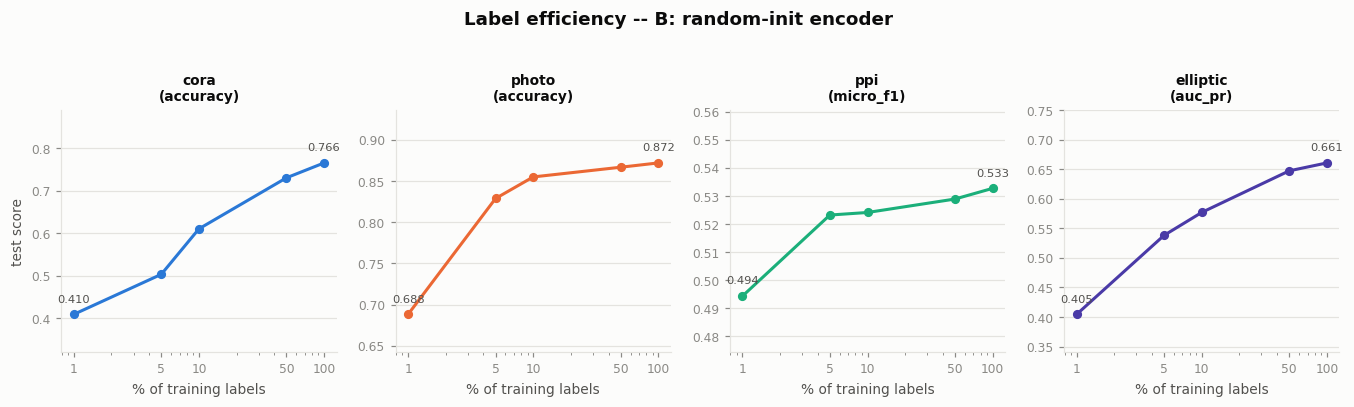

In [8]:
fig = plotting.plot_label_efficiency(sweep_df, arm_label="B: random-init encoder")

## 6. The guarantee: test is read once

Worth stating precisely, because it is the claim that makes every number
downstream meaningful.

- The SVD basis and structural scaler were fit on **training** nodes
  (notebook 02, verified by `tests/test_no_leakage.py`).
- Embedding standardization is fit on **training** nodes, and uses no labels.
- Probe early stopping watches **validation** only - `train_linear_probe`
  never evaluates test inside its loop.
- Test is scored exactly once per run, after the best-validation checkpoint
  has been restored.

In [9]:
import inspect

source = inspect.getsource(probe.train_linear_probe)
loop_body = source[source.index("for epoch in range"):source.index("result.epochs_run")]

# Strip comments first -- otherwise this check trips over the comment inside
# the loop that says "Test is not read anywhere in this loop", which is prose,
# not a data access.
code_lines = []
for line in loop_body.splitlines():
    stripped = line.split("#", 1)[0].rstrip()
    if stripped.strip():
        code_lines.append(stripped)

offenders = [ln.strip() for ln in code_lines if "test" in ln.lower()]
print(f"lines of CODE in the probe's training loop: {len(code_lines)}")
print(f"of those, lines touching test data        : {len(offenders)}")
for ln in offenders:
    print("   ", ln)

assert not offenders, "the probe training loop references test data"
print()
print("Confirmed mechanically: the training loop cannot see test data.")
print("Test is scored once, after the best-validation checkpoint is restored.")

lines of CODE in the probe's training loop: 25
of those, lines touching test data        : 0

Confirmed mechanically: the training loop cannot see test data.
Test is scored once, after the best-validation checkpoint is restored.


## What you should now understand

- **Arm B and arm C bracket every later result.** Arm B is a demanding floor,
  not a formality: a random-init GIN plus a linear probe already scores far
  above the no-model baseline on all four domains, because message passing
  alone does real work. The gap from B to C is the entire space in which
  pretraining can demonstrate value.
- **A measuring instrument needs checking before it is trusted.** The probe as
  originally specified stopped at 300 epochs while validation was still
  improving, understating Elliptic's AUC-PR by 46%. The fix - standardized
  embeddings and a budget large enough to plateau - is an optimiser change
  applied identically to every arm, which is what makes it a correction rather
  than tuning. `converged` is asserted, not hoped for.
- **Test is read exactly once per run.** Every fitted object - SVD basis,
  structural scaler, embedding standardizer - is fit on training nodes, and
  early stopping watches validation only. The assertion at the end of section
  6 checks this mechanically rather than trusting the prose.

**Next:** `05_smoke_test.ipynb` - one full fold with all four arms on a tiny
budget, to shake out the run harness before the 12-run matrix.